# Colorectal Cancer Detection using Gut Microbiome Data

### Project Overview
This project aims to develop a machine learning pipeline to distinguish between patients with **Colorectal Cancer (CRC)** and healthy individuals based on their gut microbiome composition. 

**Key Characteristics:**
* **Data Source:** 16S rRNA sequencing data at the genus/species level.
* **Dataset Size:** 60 samples (Healthy vs. Disease).
* **Methods:** Statistical screening (Mann-Whitney U), Feature Engineering, and Comparative Modeling.
* **Validation & Metrics:** 5-fold Cross-Validation and ROC-AUC analysis for model reliability.
* **Models:** Random Forest and XGBoost with a focus on Feature Importance.

In [1]:
import pandas as pd
import numpy as np
import os
import kagglehub

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc

## Step 1: Data Integration & Taxonomy Mapping

The core dataset is prepared by consolidating disparate microbiome data sources, including patient metadata, sequencing tables (ASVs), and taxonomic classifications:

1. **Data Retrieval:** Downloading the CRC (Colorectal Cancer) gut microbiome dataset.

2. **Table Merging:** Aligning patient metadata with their respective microbial profiles using a standardized `Real_ID`.

3. **Taxonomy Mapping:** Converting cryptic sequence IDs (like "ASV_1") into human-readable bacterial names (`Genus_Species`). This step is crucial for the biological interpretability of the predictive model.

In [2]:
path = kagglehub.dataset_download('aramelheni/crc-gut-microbiome-ml-data')

# 1.1 Data Retrieval
df_meta = pd.read_csv(os.path.join(path, 'metadata.csv'), sep=';')
df_seqtab = pd.read_excel(os.path.join(path, 'seqtab_nochim_export.xlsx'))
df_taxa = pd.read_excel(os.path.join(path, 'taxa_species_export.xlsx'))

# 1.2 Table Merging
df_meta['Real_ID'] = df_meta['host_disease'].str.split(';').str[0]
df_seqtab.rename(columns={df_seqtab.columns[0]: 'Real_ID'}, inplace=True)
df = pd.merge(df_meta, df_seqtab, on='Real_ID')

# 1.3 Taxonomy Mapping
df_taxa['Taxa_Name'] = df_taxa['Genus'].fillna('Unknown') + "_" + df_taxa['Species'].fillna('sp')
taxa_dict = dict(zip(df_taxa.iloc[:, 0], df_taxa['Taxa_Name']))

df = df.rename(columns=taxa_dict).drop(columns=['Real_ID', 'host_disease'])

print(f"Final dataframe shape: {df.shape}")

Final dataframe shape: (59, 6698)


## Step 2: Target Labeling and Exploration
Clinical labels are converted into a numerical format suitable for machine learning, followed by a validation of dataset integrity:

1. **Label Encoding**: Convert the categorical `DiseaseStatus` into a numerical `Target` variable (0 for Healthy, 1 for Disease).

2. **Distribution Visualization**: Create a visual check to ensure the dataset is balanced between the two groups.

3. **Data Cleanup**: Finalize the dataframe by removing redundant categorical columns and summarizing the sample counts.

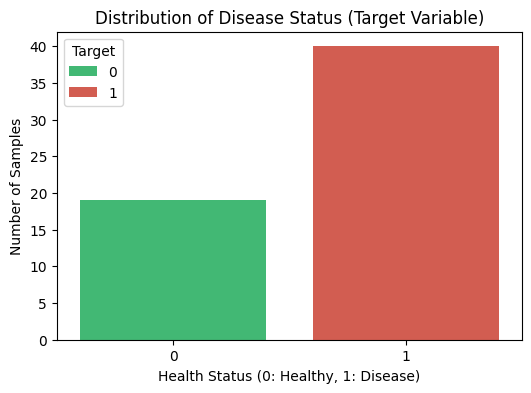

In [3]:
# 2.1. Transforming categorical status into binary format for the model
df['Target'] = df['DiseaseStatus'].apply(lambda x: 0 if x == 'Healthy' else 1)

# 2.2. Visualizing the balance between Healthy and CRC samples
plt.figure(figsize=(6,4))
custom_colors = {0: "#2ecc71", 1: "#e74c3c"}

sns.countplot(data=df, x='Target', hue='Target', palette=custom_colors)
plt.title('Distribution of Disease Status (Target Variable)')
plt.xlabel('Health Status (0: Healthy, 1: Disease)')
plt.ylabel('Number of Samples');

# 2.3. Removing the original text column and printing a final summary
df = df.drop(['DiseaseStatus'], axis=1)

## Step 3: Feature Engineering and Filtering
Microbiome datasets are typically characterized by high sparsity and skewed distributions. To ensure model stability and improve predictive performance, the following preprocessing pipeline is implemented:
1. **Aggregate duplicate taxa:** Ensure all bacterial counts are grouped correctly.

3. **Handle missing values:** Ensure all data is numeric for the ML model.

5. **Filter rare features:** Remove bacteria that appear in fewer than 10% of samples to reduce noise and prevent overfitting.

7. **Log-Normalization:** Apply $\log(1+x)$ to stabilize variance and handle skewed distributions.

In [4]:
# Data Preparation
target = df['Target'].reset_index(drop=True)
bacteria_data = df.drop(columns=['Target', 'Age', 'DiseaseStatus'], errors='ignore')

# 3.1. Merging columns with the same name by summing their values
X = bacteria_data.T.groupby(level=0).sum().T.reset_index(drop=True)

# 3.2. Standardizing data types and replacing NaN with zero values
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 3.3 Selecting columns where non-zero values exceed the 0.1 threshold
X_filtered = X.loc[:, (X > 0).mean() > 0.1]

# 3.4 Performing log-transformation to compress the range of abundance values
X_log = np.log1p(X_filtered)

print(f"Features before filtering: {X.shape[1]}")
print(f"Features after filtering (prevalence > 10%): {X_filtered.shape[1]}")
print(f"Noise reduction: {((X.shape[1] - X_filtered.shape[1]) / X.shape[1] * 100):.1f}%")

Features before filtering: 259
Features after filtering (prevalence > 10%): 115
Noise reduction: 55.6%


## Step 4: Statistical Analysis & Biomarker Selection

Differential abundance analysis is performed to identify the most relevant bacterial features. Microbiome data typically exhibits non-normal distributions and high sparsity (many zeros), necessitating robust non-parametric statistical methods:

1. **Significance Testing:** Use the **Mann-Whitney U test** to compare bacterial abundances between Healthy (0) and CRC (1) groups.

3. **Feature Reduction:** Select only bacteria with a $p$-value $< 0.05$, ensuring that the model learns from statistically significant signals rather than random noise.

5. **Results Export:** Create a ranked list of the most significant biomarkers for biological interpretation.

In [5]:
# 4.1. Using Mann-Whitney U test to compare abundance between groups
stats_list = []
for col in X_filtered.columns:
    g0 = X_filtered.loc[target == 0, col]
    g1 = X_filtered.loc[target == 1, col]
    
    if len(g0) > 0 and len(g1) > 0:
        # Performing the non-parametric test for each bacterium
        _, p = mannwhitneyu(g0, g1)
        stats_list.append({'Bacterium': col, 'p_value': p})

df_stats = pd.DataFrame(stats_list).sort_values('p_value')

# 4.2. Filtering significant features (p-value < 0.05) for the final ML model
significant_features = df_stats[df_stats['p_value'] < 0.05]['Bacterium'].tolist()
X_final = X_log[significant_features]

# 4.3. Formatting the Top 10 biomarkers for the final report
top_biomarkers = df_stats[df_stats['p_value'] < 0.05].sort_values('p_value').head(10).copy()
top_biomarkers.reset_index(drop=True, inplace=True)
top_biomarkers.index = top_biomarkers.index + 1  # Start counting from 1

print(f"Significant biomarkers identified: {len(significant_features)}")
print(f"Final feature matrix shape: {X_final.shape}")
print("\nTop 10 Significant Biomarkers:")
display(top_biomarkers)

Significant biomarkers identified: 26
Final feature matrix shape: (59, 26)

Top 10 Significant Biomarkers:


,Bacterium,p_value
1,Anaerostipes_sp,0.000017
2,Intestinibacter_bartlettii,0.000073
3,Fusicatenibacter_sp,0.000077
4,Lachnospira_pectinoschiza,0.000090
5,Christensenellaceae R-7 group_sp,0.000551
6,Lachnospiraceae UCG-010_sp,0.001784
7,Lachnospira_sp,0.002451
8,NK4A214 group_sp,0.005423
9,[Ruminococcus] torques group_sp,0.006615
10,Anaerostipes_hadrus,0.006720


## Step 5: Model Training and Evaluation

### 5.1. Model Training and Benchmarking

To ensure model reliability, validation is performed on data not used during the training phase:

1. **Data Splitting:** Divide the dataset into Training (80%) for building the model and Testing (20%) for final validation.

2. **Stratification:** Maintain the same ratio of Healthy/Disease samples in both sets to prevent bias, ensuring the model generalizes well to both classes.

3. **Model Training & Performance:** Sanitize feature names, then train and compare Random Forest and XGBoost classifiers to evaluate prediction accuracy.

In [6]:
# 5.1.1. Dividing data into 80% train and 20% test sets with balanced classes
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)

# 5.1.2. Sanitizing column names to ensure compatibility with XGBoost
X_train.columns = X_train.columns.str.replace('[', '(', regex=False).str.replace(']', ')', regex=False).str.replace('<', 'less', regex=False)
X_test.columns = X_test.columns.str.replace('[', '(', regex=False).str.replace(']', ')', regex=False).str.replace('<', 'less', regex=False)

# 5.1.3. Initializing and fitting Random Forest and XGBoost classifiers
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)

# Training models on training data and generating predictions for the test set
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.2%}")
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")

Random Forest Accuracy: 83.33%
XGBoost Accuracy: 83.33%


### 5.2. Model Reliability and Advanced Metrics
Model stability and discriminative power are validated using cross-validation and Area Under the Curve (AUC) analysis:

1. **Cross-Validation:** Implementation of a 5-fold CV to ensure the model captures general biological patterns rather than memorizing noise.

2. **ROC-AUC Calculation:** Measurement of the Area Under the Receiver Operating Characteristic Curve to evaluate the model's ability to distinguish between classes.

In [7]:
# 5.2.1. Ensuring consistent performance across various subsets of the training data
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

# 5.2.2. Utilizing probability estimates to calculate the probability of correct classification
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)

print(f" - Mean Cross-Validation Accuracy: {rf_cv_scores.mean():.2%}")
print(f" - Random Forest ROC-AUC Score: {rf_auc:.3f}")

 - Mean Cross-Validation Accuracy: 87.33%
 - Random Forest ROC-AUC Score: 0.875


### 5.3. ROC Curve Analysis

Prediction quality and the trade-off between sensitivity and specificity are evaluated visually:

1. **ROC Curve:** Graphical representation of the model's performance across all classification thresholds, allowing for the evaluation of diagnostic accuracy (AUC).

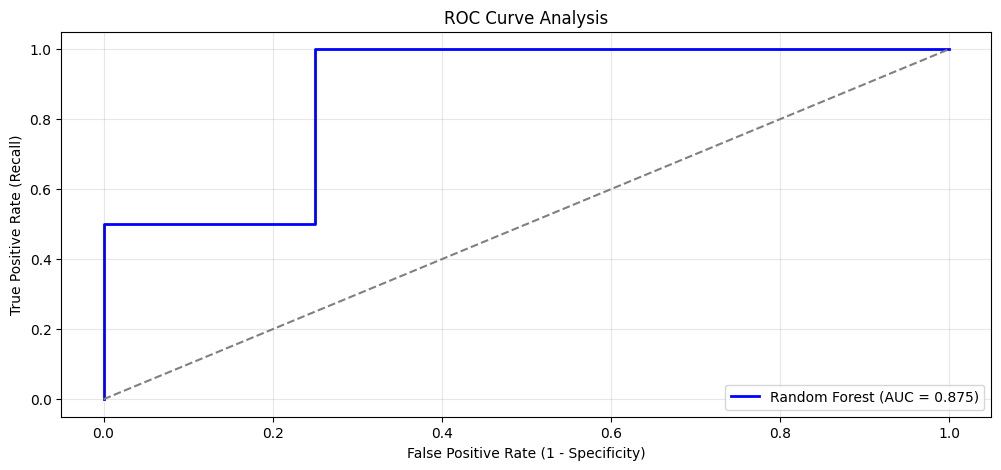

In [8]:
# 5.3.1. Generating data for the ROC Curve
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Analysis')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### 5.4. Confusion Matrix Visualization

Prediction quality is analyzed to identify specific classification errors and evaluate model reliability:

1. **Error Analysis:** Visualization of the model's predictive accuracy by comparing actual clinical status against predicted results, highlighting **True Positives** (correctly identified cases) and potential **False Negatives** (missed pathologies).

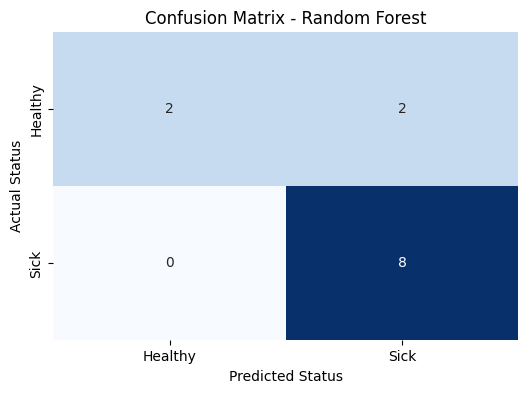

In [9]:
# 5.4.1. Visualizing the confusion matrix for the Random Forest model
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy', 'Sick'],
            yticklabels=['Healthy', 'Sick'],
            cbar=False)
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.title('Confusion Matrix - Random Forest')
plt.show()

### 5.5: Feature Importance Analysis

Primary bacterial drivers contributing to diagnostic decisions are identified to bridge the gap between machine learning performance and biological interpretation:

1. **Importance Extraction:** Retrieve weight scores from both Random Forest and XGBoost to rank the significance of each biomarker.

2. **Ranking and Sorting:** Organize the extracted scores into structured data to identify the most influential bacterial species.

3. **Comparative Visualization:** Plot the top 10 biomarkers side-by-side to verify consistent biological signals across different algorithms.

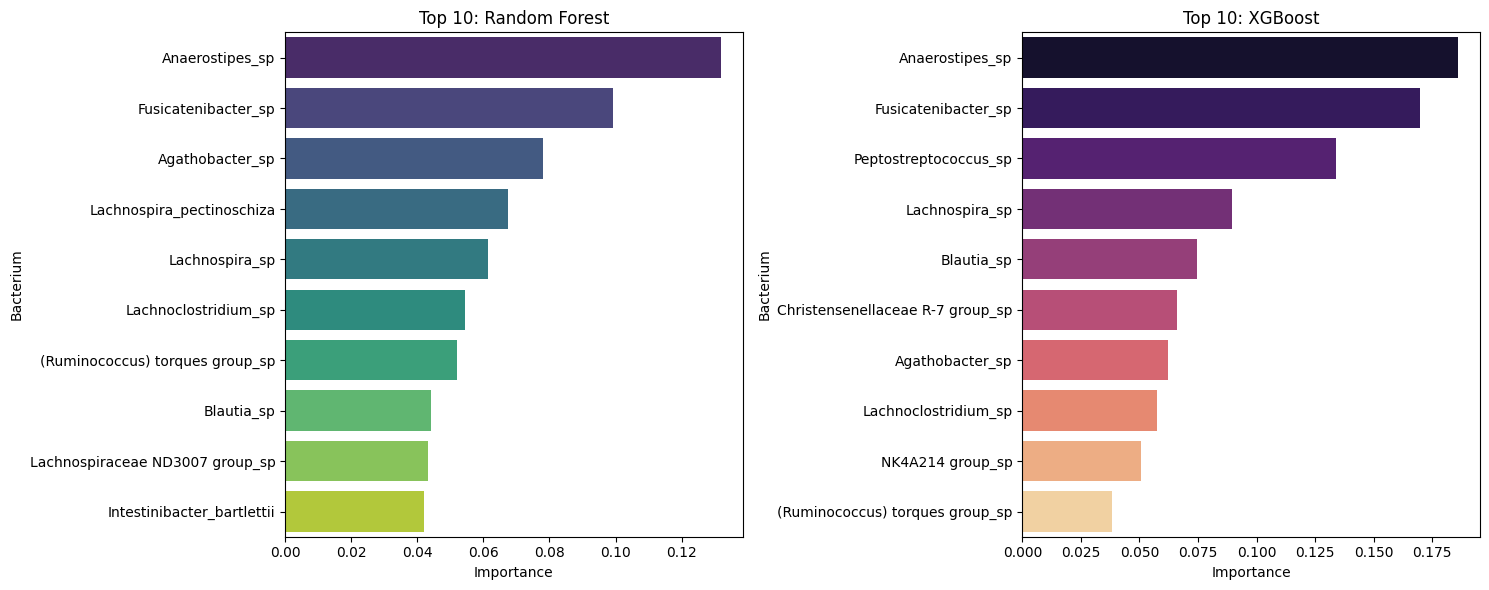

In [10]:
# 5.5.1. Retrieving contribution scores from both models
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_
feature_names = X_train.columns

# 5.5.2. Creating and sorting DataFrames for clear visualization
df_rf = pd.DataFrame({'Bacterium': feature_names, 'Importance': rf_importances}).sort_values(by='Importance', ascending=False)
df_xgb = pd.DataFrame({'Bacterium': feature_names, 'Importance': xgb_importances}).sort_values(by='Importance', ascending=False)

# 5.5.3. Plotting top 10 biomarkers side-by-side for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1 Subplot: Random Forest top 10 drivers
sns.barplot(x='Importance',
            y='Bacterium',
            data=df_rf.head(10),
            hue='Bacterium',
            palette='viridis',
            ax=ax1,
            legend=False
)
ax1.set_title('Top 10: Random Forest')

# 2 Subplot: XGBoost top 10 drivers
sns.barplot(x='Importance',
            y='Bacterium',
            data=df_xgb.head(10),
            hue='Bacterium',
            palette='magma',
            ax=ax2,
            legend=False
)
ax2.set_title('Top 10: XGBoost')

plt.tight_layout()
plt.show()

### Final Insights

**Performance:** Both models achieved 83.3% Accuracy and 100% Sensitivity (Recall), ensuring no sick patients were missed.

**AUC Score:** The Random Forest model demonstrated high discriminative power with an AUC of 0.875.

**Biomarkers:** Anaerostipes_sp and Fusicatenibacter_sp were identified as the most significant microbial predictors by both algorithms.

**Conclusion:** The high consistency between Random Forest and XGBoost confirms the robustness of these biological markers for CRC detection.